### Notebook 05 - Similarity Engine

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [2]:
listings = pd.read_csv("../Data/cleaned/listings_clean.csv")

In [3]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279599 entries, 0 to 279598
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279599 non-null  int64  
 1   name                         279424 non-null  object 
 2   host_id                      279599 non-null  int64  
 3   host_since                   279434 non-null  object 
 4   host_location                278759 non-null  object 
 5   host_response_time           150898 non-null  object 
 6   host_response_rate           150898 non-null  float64
 7   host_acceptance_rate         166577 non-null  float64
 8   host_is_superhost            279434 non-null  object 
 9   host_total_listings_count    279434 non-null  float64
 10  host_has_profile_pic         279434 non-null  object 
 11  host_identity_verified       279434 non-null  object 
 12  neighbourhood                279599 non-null  object 
 13 

In [4]:
pd.set_option("display.max_rows", None)

columns_df = pd.DataFrame({
    "Column Name": listings.columns
})

columns_df

,Column Name
0,listing_id
1,name
2,host_id
3,host_since
4,host_location
5,host_response_time
6,host_response_rate
7,host_acceptance_rate
8,host_is_superhost
9,host_total_listings_count


In [5]:
columns_df = pd.DataFrame({
    "Column Name": listings.columns,
    "Data Type": listings.dtypes.values
})

columns_df

,Column Name,Data Type
0,listing_id,int64
1,name,object
2,host_id,int64
3,host_since,object
4,host_location,object
5,host_response_time,object
6,host_response_rate,float64
7,host_acceptance_rate,float64
8,host_is_superhost,object
9,host_total_listings_count,float64


In [6]:
listings['neighbourhood'].value_counts()

neighbourhood
I Centro Storico              14869
Sydney                         8074
Copacabana                     7708
Cuauhtemoc                     7623
Buttes-Montmartre              7235
Beyoglu                        6673
Popincourt                     6204
Vaugirard                      4815
Waverley                       4737
Enclos-St-Laurent              4622
Batignolles-Monceau            4327
Menilmontant                   3757
Buttes-Chaumont                3728
Sisli                          3522
Fatih                          3325
Ward 115                       3293
Miguel Hidalgo                 3287
Passy                          3213
Opera                          3153
Benito Juarez                  3132
Randwick                       3045
Yau Tsim Mong                  3038
Temple                         2943
Williamsburg                   2731
Barra da Tijuca                2723
Bedford-Stuyvesant             2711
Reuilly                        2652
Ipanema       

In [7]:
similarity_df = listings[
    [
        "listing_id",
        "city",
        "neighbourhood",
        "property_type",
        "room_type",
        "accommodates",
        "bedrooms",
        "amenities"
    ]
].copy()

In [8]:
listings.columns

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'city', 'latitude', 'longitude', 'property_type', 'room_type',
       'accommodates', 'bedrooms', 'amenities', 'price', 'minimum_nights',
       'maximum_nights', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable'],
      dtype='object')

In [9]:
similarity_df = similarity_df.merge(
    listings[["listing_id", "price"]],
    on="listing_id",
    how="left"
)

In [10]:
level1_counts = (
    similarity_df
    .groupby(
        [
            "city",
            "neighbourhood",
            "property_type",
            "room_type"
        ]
    )
    .size()
    .reset_index(name="Level1_Candidates")
)

In [11]:
similarity_df = similarity_df.merge(
    level1_counts,
    on=[
        "city",
        "neighbourhood",
        "property_type",
        "room_type"
    ],
    how="left"
)

In [12]:
similarity_df["Level1_Candidates"].describe()

count    279599.00000
mean       1397.09093
std        1997.05981
min           1.00000
25%          79.00000
50%         483.00000
75%        1896.00000
max        8510.00000
Name: Level1_Candidates, dtype: float64

In [13]:
similarity_df["Level1_Candidates"].value_counts().sort_index().head(20)

Level1_Candidates
1     3121
2     2538
3     2229
4     2008
5     2010
6     1788
7     1729
8     1712
9     1620
10    1280
11    1452
12    1248
13    1092
14    1442
15    1290
16    1232
17    1020
18    1404
19    1064
20    1040
Name: count, dtype: int64

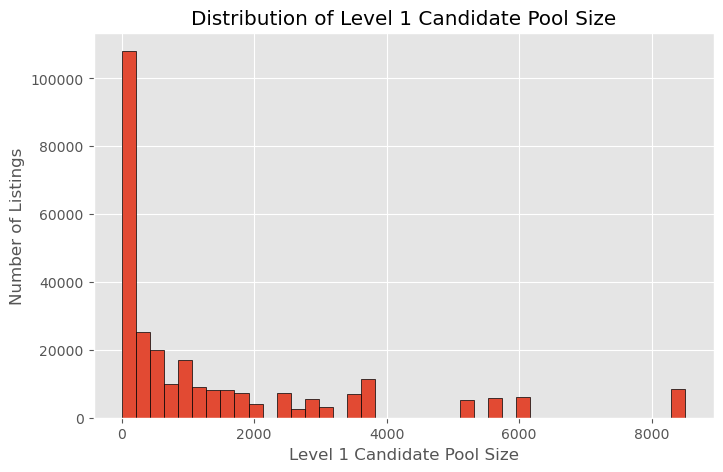

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    similarity_df["Level1_Candidates"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("Level 1 Candidate Pool Size")
plt.ylabel("Number of Listings")
plt.title("Distribution of Level 1 Candidate Pool Size")

plt.show()

In [15]:
print("Median:", similarity_df["Level1_Candidates"].median())
print("Mean:", similarity_df["Level1_Candidates"].mean())
print("Minimum:", similarity_df["Level1_Candidates"].min())
print("Maximum:", similarity_df["Level1_Candidates"].max())

Median: 483.0
Mean: 1397.0909302250723
Minimum: 1
Maximum: 8510


In [16]:
thresholds = [25, 50, 100, 200, 300, 500]

for t in thresholds:
    pct = (similarity_df["Level1_Candidates"] >= t).mean() * 100
    print(f"{t:>3} candidates : {pct:.2f}%")

 25 candidates : 86.99%
 50 candidates : 80.29%
100 candidates : 72.33%
200 candidates : 62.52%
300 candidates : 56.87%
500 candidates : 49.36%


In [17]:
similarity_df[similarity_df["Level1_Candidates"] < 100].shape

(77371, 10)

In [18]:
similarity_df[similarity_df["Level1_Candidates"] < 100][
    [
        "city",
        "neighbourhood",
        "property_type",
        "room_type",
        "Level1_Candidates"
    ]
].head(20)

,city,neighbourhood,property_type,room_type,Level1_Candidates
9239,Istanbul,Adalar,Entire apartment,Entire place,58
9244,Hong Kong,Southern,Entire apartment,Entire place,15
11615,New York,Columbia St,Entire apartment,Entire place,20
11617,New York,Inwood,Entire apartment,Entire place,72
11628,New York,Little Italy,Entire apartment,Entire place,68
11640,New York,Woodside,Entire apartment,Entire place,28
11644,New York,Ditmars Steinway,Entire apartment,Entire place,69
11648,New York,Sheepshead Bay,Entire apartment,Entire place,58
11670,New York,Brooklyn Heights,Entire apartment,Entire place,80
11673,New York,Richmond Hill,Entire apartment,Entire place,16


In [19]:
low_candidates = similarity_df[
    similarity_df["Level1_Candidates"] < 100
]

low_candidates[
    [
        "city",
        "neighbourhood",
        "property_type",
        "room_type",
        "Level1_Candidates"
    ]
].head(30)

,city,neighbourhood,property_type,room_type,Level1_Candidates
9239,Istanbul,Adalar,Entire apartment,Entire place,58
9244,Hong Kong,Southern,Entire apartment,Entire place,15
11615,New York,Columbia St,Entire apartment,Entire place,20
11617,New York,Inwood,Entire apartment,Entire place,72
11628,New York,Little Italy,Entire apartment,Entire place,68
11640,New York,Woodside,Entire apartment,Entire place,28
11644,New York,Ditmars Steinway,Entire apartment,Entire place,69
11648,New York,Sheepshead Bay,Entire apartment,Entire place,58
11670,New York,Brooklyn Heights,Entire apartment,Entire place,80
11673,New York,Richmond Hill,Entire apartment,Entire place,16


In [20]:
low_candidates["property_type"].value_counts().head(15)

property_type
Private room in apartment            8537
Entire apartment                     8007
Private room in house                7642
Entire house                         6030
Entire condominium                   4886
Private room in condominium          3628
Room in boutique hotel               3547
Entire loft                          2650
Room in hotel                        2482
Private room in townhouse            2383
Entire serviced apartment            2339
Entire guest suite                   2273
Shared room in apartment             2174
Private room in bed and breakfast    2096
Entire townhouse                     2000
Name: count, dtype: int64

In [21]:
low_candidates["room_type"].value_counts()

room_type
Private room    35563
Entire place    32749
Hotel room       4554
Shared room      4505
Name: count, dtype: int64

In [22]:
low_candidates["city"].value_counts()

city
New York          13742
Bangkok           10853
Cape Town          9845
Istanbul           8983
Sydney             8667
Rio de Janeiro     7507
Paris              5649
Mexico City        4954
Rome               4504
Hong Kong          2667
Name: count, dtype: int64

In [23]:
# Create a fresh copy
similarity_df = listings[
    [
        "listing_id",
        "city",
        "neighbourhood",
        "property_type",
        "room_type",
        "accommodates",
        "bedrooms",
        "amenities"
    ]
].copy()

In [24]:
city_counts = (
    similarity_df.groupby("city")
    .size()
    .rename("City_Candidates")
)

similarity_df = similarity_df.join(city_counts, on="city")

In [25]:
city_neighbourhood_counts = (
    similarity_df.groupby(["city", "neighbourhood"])
    .size()
    .rename("City_Neighbourhood_Candidates")
)

similarity_df = similarity_df.join(
    city_neighbourhood_counts,
    on=["city", "neighbourhood"]
)

In [26]:
city_neighbourhood_property_counts = (
    similarity_df.groupby(
        ["city", "neighbourhood", "property_type"]
    )
    .size()
    .rename("City_Neighbourhood_Property_Candidates")
)

similarity_df = similarity_df.join(
    city_neighbourhood_property_counts,
    on=["city", "neighbourhood", "property_type"]
)

In [27]:
level1_counts = (
    similarity_df.groupby(
        ["city", "neighbourhood", "property_type", "room_type"]
    )
    .size()
    .rename("Level1_Candidates")
)

similarity_df = similarity_df.join(
    level1_counts,
    on=["city", "neighbourhood", "property_type", "room_type"]
)

In [28]:
comparison = similarity_df[
    [
        "City_Candidates",
        "City_Neighbourhood_Candidates",
        "City_Neighbourhood_Property_Candidates",
        "Level1_Candidates"
    ]
].describe().T

comparison

,count,mean,std,min,25%,50%,75%,max
City_Candidates,279599.0,35551.984460,17176.397438,7087.0,24517.0,27641.0,36984.0,64628.0
City_Neighbourhood_Candidates,279599.0,3396.690178,3580.017125,1.0,824.0,2278.0,4622.0,14869.0
City_Neighbourhood_Property_Candidates,279599.0,1399.655703,1995.637132,1.0,83.0,490.0,1896.0,8510.0
Level1_Candidates,279599.0,1397.090930,1997.059810,1.0,79.0,483.0,1896.0,8510.0


                 Selected Listing
                        │
                        ▼
      Level 1: City + Neighbourhood + Property Type
                        │
            Candidates ≥ Threshold?
                  /               \
                Yes               No
                 │                 │
                 ▼                 ▼
          Run Similarity     Level 2: City + Neighbourhood
                                   │
                       Candidates ≥ Threshold?
                             /               \
                           Yes               No
                            │                 │
                            ▼                 ▼
                     Run Similarity      Level 3: City
                                               │
                                               ▼
                                        Run Similarity

In [29]:
LEVEL_1 = [
    "city",
    "neighbourhood",
    "property_type"
]

LEVEL_2 = [
    "city",
    "neighbourhood"
]

LEVEL_3 = [
    "city"
]

MIN_CANDIDATES = 100
TOP_SIMILAR = 100
BENCHMARK_PERCENTILE = 0.20

In [30]:
level_1_counts = (
    similarity_df
    .groupby(LEVEL_1)
    .size()
    .rename("Level_1_Candidates")
)

similarity_df = similarity_df.join(
    level_1_counts,
    on=LEVEL_1
)

In [31]:
similarity_df["Level_1_Candidates"].describe()

count    279599.000000
mean       1399.655703
std        1995.637132
min           1.000000
25%          83.000000
50%         490.000000
75%        1896.000000
max        8510.000000
Name: Level_1_Candidates, dtype: float64

In [32]:
thresholds = [25, 50, 100, 200, 300, 500]

for threshold in thresholds:
    
    percentage = (
        similarity_df["Level_1_Candidates"] >= threshold
    ).mean() * 100
    
    print(
        f"{threshold:>3} candidates : {percentage:.2f}%"
    )

 25 candidates : 87.36%
 50 candidates : 80.76%
100 candidates : 72.89%
200 candidates : 62.85%
300 candidates : 57.40%
500 candidates : 49.78%


In [33]:
similarity_df["Hierarchy_Level"] = 1

# Listings with insufficient candidates move to Level 2
similarity_df.loc[
    similarity_df["Level_1_Candidates"] < MIN_CANDIDATES,
    "Hierarchy_Level"
] = 2

In [34]:
similarity_df["Hierarchy_Level"].value_counts().sort_index()

Hierarchy_Level
1    203813
2     75786
Name: count, dtype: int64

In [35]:
level_2_percentage = (
    (similarity_df["Hierarchy_Level"] == 2).mean() * 100
)

print(
    f"Listings requiring Level 2: {level_2_percentage:.2f}%"
)

Listings requiring Level 2: 27.11%


In [36]:
level_2_counts = (
    similarity_df
    .groupby(LEVEL_2)
    .size()
    .rename("Level_2_Candidates")
)

similarity_df = similarity_df.join(
    level_2_counts,
    on=LEVEL_2
)

In [37]:
similarity_df.loc[
    (similarity_df["Hierarchy_Level"] == 2) &
    (similarity_df["Level_2_Candidates"] < MIN_CANDIDATES),
    "Hierarchy_Level"
] = 3

In [38]:
similarity_df["Hierarchy_Level"].value_counts().sort_index()

Hierarchy_Level
1    203813
2     66458
3      9328
Name: count, dtype: int64

In [39]:
hierarchy_distribution = (
    similarity_df["Hierarchy_Level"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(hierarchy_distribution)

Hierarchy_Level
1    72.894753
2    23.769041
3     3.336206
Name: proportion, dtype: float64


In [40]:
level_3_counts = (
    similarity_df
    .groupby(LEVEL_3)
    .size()
    .rename("Level_3_Candidates")
)

similarity_df = similarity_df.join(
    level_3_counts,
    on=LEVEL_3
)

In [41]:
similarity_df["Final_Candidate_Count"] = np.nan

# Listings matched at Level 1
similarity_df.loc[
    similarity_df["Hierarchy_Level"] == 1,
    "Final_Candidate_Count"
] = similarity_df["Level_1_Candidates"]

# Listings matched at Level 2
similarity_df.loc[
    similarity_df["Hierarchy_Level"] == 2,
    "Final_Candidate_Count"
] = similarity_df["Level_2_Candidates"]

# Listings matched at Level 3
similarity_df.loc[
    similarity_df["Hierarchy_Level"] == 3,
    "Final_Candidate_Count"
] = similarity_df["Level_3_Candidates"]

In [42]:
similarity_df[
    [
        "Hierarchy_Level",
        "Level_1_Candidates",
        "Level_2_Candidates",
        "Level_3_Candidates",
        "Final_Candidate_Count"
    ]
].head(15)

,Hierarchy_Level,Level_1_Candidates,Level_2_Candidates,Level_3_Candidates,Final_Candidate_Count
0,1,6040,7235,64628,6040.0
1,1,6040,7235,64628,6040.0
2,1,1295,1761,64628,1295.0
3,1,3807,4815,64628,3807.0
4,1,2609,3213,64628,2609.0
5,1,2540,2943,64628,2540.0
6,1,5149,6204,64628,5149.0
7,1,5149,6204,64628,5149.0
8,1,2769,3728,64628,2769.0
9,1,2378,3153,64628,2378.0


In [43]:
similarity_df["Final_Candidate_Count"].describe()

count    279599.000000
mean       2713.048988
std        5521.922074
min         100.000000
25%         338.000000
50%         976.000000
75%        2769.000000
max       36984.000000
Name: Final_Candidate_Count, dtype: float64

In [44]:
similarity_df.loc[
    similarity_df["Hierarchy_Level"] == 2,
    [
        "Hierarchy_Level",
        "Level_1_Candidates",
        "Level_2_Candidates",
        "Level_3_Candidates",
        "Final_Candidate_Count"
    ]
].head(10)

,Hierarchy_Level,Level_1_Candidates,Level_2_Candidates,Level_3_Candidates,Final_Candidate_Count
9239,2,58,195,24517,195.0
11617,2,72,175,36984,175.0
11628,2,68,102,36984,102.0
11640,2,28,363,36984,363.0
11644,2,69,223,36984,223.0
11648,2,58,134,36984,134.0
11670,2,80,109,36984,109.0
11685,2,78,291,36984,291.0
11690,2,72,175,36984,175.0
11707,2,72,175,36984,175.0


In [45]:
similarity_df.loc[
    similarity_df["Hierarchy_Level"] == 3,
    [
        "Hierarchy_Level",
        "Level_1_Candidates",
        "Level_2_Candidates",
        "Level_3_Candidates",
        "Final_Candidate_Count"
    ]
].head(10)

,Hierarchy_Level,Level_1_Candidates,Level_2_Candidates,Level_3_Candidates,Final_Candidate_Count
9244,3,15,48,7087,7087.0
11615,3,20,34,36984,36984.0
11673,3,16,73,36984,36984.0
11675,3,8,48,36984,36984.0
11682,3,50,75,36984,36984.0
11696,3,44,69,36984,36984.0
11744,3,17,89,36984,36984.0
11781,3,50,75,36984,36984.0
11787,3,12,54,36984,36984.0
11803,3,13,30,36984,36984.0


In [46]:
similarity_df["Matching_Strategy"] = similarity_df["Hierarchy_Level"].map({
    1: "City + Neighbourhood + Property Type",
    2: "City + Neighbourhood",
    3: "City"
})

In [47]:
similarity_df.head(5)

,listing_id,city,neighbourhood,property_type,room_type,accommodates,bedrooms,amenities,City_Candidates,City_Neighbourhood_Candidates,City_Neighbourhood_Property_Candidates,Level1_Candidates,Level_1_Candidates,Hierarchy_Level,Level_2_Candidates,Level_3_Candidates,Final_Candidate_Count,Matching_Strategy
0,281420,Paris,Buttes-Montmartre,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",64628,7235,6040,6040,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type
1,3705183,Paris,Buttes-Montmartre,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",64628,7235,6040,6040,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type
2,4082273,Paris,Elysee,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",64628,1761,1295,1295,1295,1,1761,64628,1295.0,City + Neighbourhood + Property Type
3,4797344,Paris,Vaugirard,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",64628,4815,3807,3807,3807,1,4815,64628,3807.0,City + Neighbourhood + Property Type
4,4823489,Paris,Passy,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",64628,3213,2609,2609,2609,1,3213,64628,2609.0,City + Neighbourhood + Property Type


## In this phase, we developed a hierarchical candidate retrieval engine that automatically identifies an appropriate comparison pool for every Airbnb listing by progressively relaxing matching constraints until a minimum of 100 comparable listings is obtained.

In [48]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279599 entries, 0 to 279598
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279599 non-null  int64  
 1   name                         279424 non-null  object 
 2   host_id                      279599 non-null  int64  
 3   host_since                   279434 non-null  object 
 4   host_location                278759 non-null  object 
 5   host_response_time           150898 non-null  object 
 6   host_response_rate           150898 non-null  float64
 7   host_acceptance_rate         166577 non-null  float64
 8   host_is_superhost            279434 non-null  object 
 9   host_total_listings_count    279434 non-null  float64
 10  host_has_profile_pic         279434 non-null  object 
 11  host_identity_verified       279434 non-null  object 
 12  neighbourhood                279599 non-null  object 
 13 

In [49]:
similarity_df['amenities'].iloc[0]

'["Heating", "Kitchen", "Washer", "Wifi", "Long term stays allowed"]'

### Phase 2: Similarity Ranking

In [50]:
import ast



# Create raw amenities count
similarity_df["amenities_count"] = (
    similarity_df["amenities"]
    .fillna("[]")
    .apply(lambda x: len(ast.literal_eval(x)))
)

In [51]:


SIMILARITY_FEATURES = [
    "accommodates",
    "bedrooms",
    "amenities_count"
]

TOP_SIMILAR = 100

In [52]:
# Impute Missing Bedrooms

median_bedrooms = similarity_df["bedrooms"].median()

similarity_df["bedrooms"] = (
    similarity_df["bedrooms"]
    .fillna(median_bedrooms)
)

In [53]:
similarity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279599 entries, 0 to 279598
Data columns (total 19 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   listing_id                              279599 non-null  int64  
 1   city                                    279599 non-null  object 
 2   neighbourhood                           279599 non-null  object 
 3   property_type                           279599 non-null  object 
 4   room_type                               279599 non-null  object 
 5   accommodates                            279599 non-null  int64  
 6   bedrooms                                279599 non-null  float64
 7   amenities                               279599 non-null  object 
 8   City_Candidates                         279599 non-null  int64  
 9   City_Neighbourhood_Candidates           279599 non-null  int64  
 10  City_Neighbourhood_Property_Candidates  2795

In [54]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

similarity_df[SIMILARITY_FEATURES] = scaler.fit_transform(
    similarity_df[SIMILARITY_FEATURES]
)

In [55]:
similarity_df[SIMILARITY_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
accommodates,279599.0,0.152649,0.142200,0.0,0.066667,0.066667,0.200000,1.0
bedrooms,279599.0,0.009417,0.022496,0.0,0.000000,0.000000,0.020408,1.0
amenities_count,279599.0,0.219730,0.103865,0.0,0.146067,0.202247,0.292135,1.0


In [56]:
import ast

# Save the scaled version for KNN
similarity_df["amenities_count_scaled"] = similarity_df["amenities_count"]

# Recreate the raw count
similarity_df["amenities_count"] = (
    similarity_df["amenities"]
    .fillna("[]")
    .apply(lambda x: len(ast.literal_eval(x)))
)

In [57]:
# Hierarchical Filter Mapping

LEVEL_FILTERS = {
    1: ["city", "neighbourhood", "property_type"],
    2: ["city", "neighbourhood"],
    3: ["city"]
}

In [58]:
def get_candidate_pool(listing_id):

    # Retrieve the selected listing
    target = similarity_df.loc[
        similarity_df["listing_id"] == listing_id
    ]

    if target.empty:
        raise ValueError(f"Listing ID {listing_id} not found.")

    target = target.iloc[0]

    # Determine hierarchy level
    hierarchy_level = target["Hierarchy_Level"]

    # Get the required filters
    filters = LEVEL_FILTERS[hierarchy_level]

    # Start with all listings
    candidate_pool = similarity_df.copy()

    # Apply each filter dynamically
    for column in filters:
        candidate_pool = candidate_pool[
            candidate_pool[column] == target[column]
        ]

    # Remove the listing itself
    candidate_pool = candidate_pool[
        candidate_pool["listing_id"] != listing_id
    ]

    return candidate_pool

In [59]:
sample_listing = similarity_df.iloc[0]["listing_id"]

candidate_pool = get_candidate_pool(sample_listing)

print(candidate_pool.shape)

candidate_pool.head()

(6039, 20)


,listing_id,city,neighbourhood,property_type,room_type,accommodates,bedrooms,amenities,City_Candidates,City_Neighbourhood_Candidates,City_Neighbourhood_Property_Candidates,Level1_Candidates,Level_1_Candidates,Hierarchy_Level,Level_2_Candidates,Level_3_Candidates,Final_Candidate_Count,Matching_Strategy,amenities_count,amenities_count_scaled
1,3705183,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",64628,7235,6040,6040,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,8,0.089888
28,13857048,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Iron"", ""Heating"", ""Washer"", ""Elevator"", ""Hai...",64628,7235,6040,6040,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,10,0.112360
29,13893805,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Iron"", ""Shampoo"", ""Heating"", ""Washer"", ""Hair...",64628,7235,6040,6040,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,16,0.179775
43,17843771,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Iron"", ""Heating"", ""Washer"", ""Hair dryer"", ""D...",64628,7235,6040,6040,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,15,0.168539
50,19944091,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Shampoo"", ""Heating"", ""Washer"", ""Hair dryer"",...",64628,7235,6040,6040,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,12,0.134831


In [60]:
sample_listing = similarity_df.iloc[0]

print("Expected:")
print(sample_listing["Final_Candidate_Count"])

print()

print("Returned:")
print(len(candidate_pool))

Expected:
6040.0

Returned:
6039


In [61]:
sample_listing = similarity_df.iloc[0]

print(sample_listing[[
    "city",
    "neighbourhood",
    "property_type",
    "Hierarchy_Level"
]])

city                           Paris
neighbourhood      Buttes-Montmartre
property_type       Entire apartment
Hierarchy_Level                    1
Name: 0, dtype: object


In [62]:
candidate_pool[[
    "city",
    "neighbourhood",
    "property_type"
]].head()

,city,neighbourhood,property_type
1,Paris,Buttes-Montmartre,Entire apartment
28,Paris,Buttes-Montmartre,Entire apartment
29,Paris,Buttes-Montmartre,Entire apartment
43,Paris,Buttes-Montmartre,Entire apartment
50,Paris,Buttes-Montmartre,Entire apartment


A hierarchical candidate retrieval function was developed to dynamically identify the comparison pool for any listing based on its assigned hierarchy level. The retrieved candidate pool was validated by confirming both the expected pool size and the consistency of all hierarchy-specific filtering criteria.

In [63]:
from sklearn.neighbors import NearestNeighbors

In [64]:
# Similarity Ranking Function


def get_similar_listings(listing_id, top_similar=100):

    # Retrieve candidate pool
    candidate_pool = get_candidate_pool(listing_id).copy()

    # Retrieve target listing
    target = similarity_df.loc[
        similarity_df["listing_id"] == listing_id,
        SIMILARITY_FEATURES
    ]

    # Candidate features
    X_candidates = candidate_pool[SIMILARITY_FEATURES]

    # Number of neighbours to retrieve
    n_neighbors = min(top_similar, len(candidate_pool))

    # Fit KNN
    knn = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric="euclidean"
    )

    knn.fit(X_candidates)

    # Find neighbours
    distances, indices = knn.kneighbors(target)

    # Retrieve similar listings
    similar_listings = candidate_pool.iloc[indices[0]].copy()

    # Add ranking information
    similar_listings["Distance"] = distances[0]
    similar_listings["Similarity_Rank"] = range(1, len(similar_listings) + 1)

    return similar_listings

In [65]:
sample_listing = similarity_df.iloc[0]["listing_id"]

similar_listings = get_similar_listings(sample_listing)

print(similar_listings.shape)

similar_listings.head(20)

(100, 22)


,listing_id,city,neighbourhood,property_type,room_type,accommodates,bedrooms,amenities,City_Candidates,City_Neighbourhood_Candidates,...,Level_1_Candidates,Hierarchy_Level,Level_2_Candidates,Level_3_Candidates,Final_Candidate_Count,Matching_Strategy,amenities_count,amenities_count_scaled,Distance,Similarity_Rank
226012,39299963,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""TV"", ""Essentials"", ""Hot water"", ""Wifi"", ""Lon...",64628,7235,...,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,5,0.05618,0.0,1
6152,12154596,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Heating"", ""Essentials"", ""Hair dryer"", ""Wifi""...",64628,7235,...,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,5,0.05618,0.0,2
234287,45211303,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Hair dryer"", ""Smoke alarm"", ""Wifi"", ""Kitchen...",64628,7235,...,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,5,0.05618,0.0,3
279416,2072767,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Elev...",64628,7235,...,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,5,0.05618,0.0,4
57933,37118410,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Kitchen"", ""Long term stays allowed"", ""Washer...",64628,7235,...,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,5,0.05618,0.0,5
275202,25186475,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Washer"", ""Wifi"", ""Kitchen"", ""Long term stays...",64628,7235,...,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,5,0.05618,0.0,6
12417,38616836,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Shampoo"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",64628,7235,...,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,5,0.05618,0.0,7
258478,10329466,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Heating"", ""Kitchen"", ""Wifi"", ""Elevator"", ""De...",64628,7235,...,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,5,0.05618,0.0,8
277828,311499,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""TV"", ""Kitchen"", ""Wifi"", ""Long term stays all...",64628,7235,...,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,5,0.05618,0.0,9
277871,4832122,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",64628,7235,...,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,5,0.05618,0.0,10


### Phase 3 — Benchmark Construction

In [66]:
master = pd.read_csv("Feature engineering/data/StayScore_Output.csv")

In [67]:
BENCHMARK_PERCENTILE = 0.20

In [68]:
def build_benchmark(listing_id):

    # Retrieve similar listings
    similar_listings = get_similar_listings(listing_id)
    
    # Step 2: Attach KPI scores
    similar_listings = similar_listings.merge(
        master[
            [
                "listing_id",
                "StayScore",
                "HostTrust",
                "ListingIQ",
                "ExperienceIQ"
            ]
        ],
        on="listing_id",
        how="left"
    )
  
    
    # Sort by StayScore (Highest first)
    similar_listings = similar_listings.sort_values(
        by="StayScore",
        ascending=False
    )

    
    # Number of benchmark listings
    benchmark_size = max(
        1,
        int(len(similar_listings) * BENCHMARK_PERCENTILE)
    )

    # Select benchmark
    benchmark = similar_listings.head(benchmark_size).copy()

    benchmark = benchmark.reset_index(drop=True)

    benchmark["Benchmark_Rank"] = benchmark.index + 1

    return benchmark

In [69]:
sample_listing = similarity_df.iloc[0]["listing_id"]

benchmark = build_benchmark(sample_listing)

print("Benchmark Size:", len(benchmark))

benchmark[
    ["listing_id", "StayScore", "Similarity_Rank", "Benchmark_Rank", "Distance"]
].head()

Benchmark Size: 20


,listing_id,StayScore,Similarity_Rank,Benchmark_Rank,Distance
0,1010134,58.623149,79,1,0.269772
1,206216,58.275491,92,2,1.000000
2,578990,56.968357,30,3,0.000000
3,3292531,56.357053,65,4,0.133333
4,6803450,56.236336,47,5,0.000000


In [70]:
benchmark.columns

Index(['listing_id', 'city', 'neighbourhood', 'property_type', 'room_type',
       'accommodates', 'bedrooms', 'amenities', 'City_Candidates',
       'City_Neighbourhood_Candidates',
       'City_Neighbourhood_Property_Candidates', 'Level1_Candidates',
       'Level_1_Candidates', 'Hierarchy_Level', 'Level_2_Candidates',
       'Level_3_Candidates', 'Final_Candidate_Count', 'Matching_Strategy',
       'amenities_count', 'amenities_count_scaled', 'Distance',
       'Similarity_Rank', 'StayScore', 'HostTrust', 'ListingIQ',
       'ExperienceIQ', 'Benchmark_Rank'],
      dtype='object')

In [71]:
build_benchmark(7357218)

,listing_id,city,neighbourhood,property_type,room_type,accommodates,bedrooms,amenities,City_Candidates,City_Neighbourhood_Candidates,...,Matching_Strategy,amenities_count,amenities_count_scaled,Distance,Similarity_Rank,StayScore,HostTrust,ListingIQ,ExperienceIQ,Benchmark_Rank
0,4666455,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Wa...",64628,7235,...,City + Neighbourhood + Property Type,6,0.067416,0.0,19,59.028418,49.698909,28.598844,98.7875,1
1,533951,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Elev...",64628,7235,...,City + Neighbourhood + Property Type,6,0.067416,0.0,27,57.184770,49.402290,22.152020,100.0000,2
2,36408245,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Washer"", ""Dryer"", ""Wifi"", ""Smoke alarm"", ""Es...",64628,7235,...,City + Neighbourhood + Property Type,6,0.067416,0.0,75,56.973541,48.768602,22.152020,100.0000,3
3,43977538,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Hot water"",...",64628,7235,...,City + Neighbourhood + Property Type,6,0.067416,0.0,71,56.329291,40.389030,28.598844,100.0000,4
4,6689342,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",64628,7235,...,City + Neighbourhood + Property Type,6,0.067416,0.0,91,56.255160,40.166636,28.598844,100.0000,5
5,6594258,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",64628,7235,...,City + Neighbourhood + Property Type,6,0.067416,0.0,12,55.261237,43.631691,22.152020,100.0000,6
6,11504261,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Heating"", ""Kitchen"", ""Essentials"", ""Smoke al...",64628,7235,...,City + Neighbourhood + Property Type,6,0.067416,0.0,5,53.932607,40.678979,28.598844,92.5200,7
7,3478239,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",64628,7235,...,City + Neighbourhood + Property Type,6,0.067416,0.0,24,53.868169,33.005664,28.598844,100.0000,8
8,728164,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",64628,7235,...,City + Neighbourhood + Property Type,6,0.067416,0.0,90,53.765938,47.838296,22.152020,91.3075,9
9,19242865,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Dedicated workspace"", ""Wifi"", ""Kitchen"", ""Es...",64628,7235,...,City + Neighbourhood + Property Type,6,0.067416,0.0,73,53.432083,38.144230,22.152020,100.0000,10


### Recommendation Engine

In [72]:
similarity_df = similarity_df.merge(
    listings[["listing_id", "price"]],
    on="listing_id",
    how="left"
)

In [73]:
COMPARISON_METRICS = [
    "StayScore",
    "HostTrust",
    "ListingIQ",
    "ExperienceIQ",
    "price",
    "amenities_count"
]

In [74]:
# =====================================================
# Benchmark Summary
# =====================================================

def get_benchmark_summary(benchmark):

    benchmark_summary = (
        benchmark[COMPARISON_METRICS]
        .mean()
        .to_frame(name="Benchmark")
        .reset_index()
        .rename(columns={"index": "Metric"})
    )

    return benchmark_summary

In [75]:
sample_listing = similarity_df.iloc[0]["listing_id"]

benchmark = build_benchmark(sample_listing)

benchmark_summary = get_benchmark_summary(benchmark)

benchmark_summary

,Metric,Benchmark
0,StayScore,54.613155
1,HostTrust,39.730896
2,ListingIQ,25.725819
3,ExperienceIQ,98.382750
4,price,68.450000
5,amenities_count,4.900000


In [76]:
def compare_to_benchmark(listing_id, benchmark_summary):

    # Retrieve target KPIs
    target = master.loc[
        master["listing_id"] == listing_id,
        [
            "listing_id",
            "StayScore",
            "HostTrust",
            "ListingIQ",
            "ExperienceIQ"
        ]
    ].copy()

    # Retrieve target business metrics
    target = target.merge(
        similarity_df[
            [
                "listing_id",
                "price",
                "amenities_count"
            ]
        ],
        on="listing_id",
        how="left"
    )

    target = target.iloc[0]

    # Build comparison table
    comparison = benchmark_summary.copy()

    target_values = []

    for metric in comparison["Metric"]:
        target_values.append(target[metric])

    comparison["Target"] = target_values

    comparison["Difference"] = (
        comparison["Target"] - comparison["Benchmark"]
    )

    comparison["Gap (%)"] = (
        comparison["Difference"] /
        comparison["Benchmark"] * 100
    ).round(2)

    return comparison

In [77]:
sample_listing = similarity_df.iloc[0]["listing_id"]

benchmark = build_benchmark(sample_listing)

benchmark_summary = get_benchmark_summary(benchmark)

comparison = compare_to_benchmark(
    sample_listing,
    benchmark_summary
)

comparison

,Metric,Benchmark,Target,Difference,Gap (%)
0,StayScore,54.613155,55.763351,1.150196,2.11
1,HostTrust,39.730896,45.477167,5.746271,14.46
2,ListingIQ,25.725819,21.812885,-3.912934,-15.21
3,ExperienceIQ,98.382750,100.000000,1.617250,1.64
4,price,68.450000,53.000000,-15.450000,-22.57
5,amenities_count,4.900000,5.000000,0.100000,2.04


In [90]:
# =====================================================
# Generate Recommendations
# =====================================================

def generate_recommendations(comparison):

    recommendations = comparison.copy()

    priorities = []
    recommendation_text = []

    for _, row in recommendations.iterrows():

        metric = row["Metric"]
        benchmark = row["Benchmark"]
        target = row["Target"]
        gap = row["Gap (%)"]

        # -----------------------------------------
        # Missing KPI Check
        # -----------------------------------------

        if pd.isna(target) or pd.isna(benchmark) or pd.isna(gap):

            priorities.append("Unavailable")

            recommendation_text.append(
                f"{metric} could not be evaluated because insufficient review data was available to calculate this performance metric."
            )

            continue

        # -----------------------------------------
        # Priority Assignment
        # -----------------------------------------

        if gap >= 0:
            priority = "Strength"

        elif gap <= -20:
            priority = "High"

        elif gap <= -10:
            priority = "Medium"

        else:
            priority = "Low"

        priorities.append(priority)

        # -----------------------------------------
        # Dynamic Recommendation
        # -----------------------------------------

        if metric == "StayScore":

            if gap < 0:
                text = (
                    f"Your StayScore is {target:.2f} compared to the benchmark "
                    f"of {benchmark:.2f} ({abs(gap):.2f}% lower). "
                    "Improving your overall listing performance will help you compete "
                    "with similar high-performing listings."
                )
            else:
                text = (
                    f"Your StayScore is {gap:.2f}% above the benchmark. "
                    "Continue maintaining your overall listing quality."
                )

        elif metric == "HostTrust":

            if gap < 0:
                text = (
                    f"Your HostTrust is {target:.2f} compared to the benchmark "
                    f"of {benchmark:.2f}. "
                    "Improving responsiveness, profile completeness and guest confidence "
                    "can further strengthen your performance."
                )
            else:
                text = (
                    f"Your HostTrust exceeds the benchmark by {gap:.2f}%. "
                    "Continue maintaining excellent host standards."
                )

        elif metric == "ListingIQ":

            if gap < 0:
                text = (
                    f"Your ListingIQ is {target:.2f} compared to the benchmark "
                    f"of {benchmark:.2f}. "
                    "Enhancing your listing description, photos and amenities can "
                    "improve your competitiveness."
                )
            else:
                text = (
                    f"Your ListingIQ is {gap:.2f}% above the benchmark. "
                    "Maintain the quality and completeness of your listing."
                )

        elif metric == "ExperienceIQ":

            if gap < 0:
                text = (
                    f"Your ExperienceIQ is {target:.2f} compared to the benchmark "
                    f"of {benchmark:.2f}. "
                    "Focus on maintaining excellent guest reviews and service quality."
                )
            else:
                text = (
                    f"Your ExperienceIQ exceeds comparable listings by {gap:.2f}%. "
                    "Keep delivering an outstanding guest experience."
                )

        elif metric == "price":

            if gap < 0:
                text = (
                    f"Your average nightly price is {target:.2f}, while similar "
                    f"high-performing listings average {benchmark:.2f}. "
                    "After improving your listing quality, consider reviewing your pricing strategy."
                )
            else:
                text = (
                    f"Your average nightly price is {target:.2f}, approximately "
                    f"{gap:.2f}% above comparable listings. Ensure the premium is supported "
                    "by superior listing quality and guest experience."
                )

        elif metric == "amenities_count":

            if gap < 0:
                text = (
                    f"Benchmark listings provide an average of {benchmark:.0f} amenities, "
                    f"while your listing offers {target:.0f}. "
                    "Adding more amenities could improve your competitiveness."
                )
            else:
                text = (
                    f"Your listing offers {target:.0f} amenities, which is above the "
                    "benchmark. Continue maintaining this advantage."
                )

        recommendation_text.append(text)

    recommendations["Priority"] = priorities
    recommendations["Recommendation"] = recommendation_text

    # -----------------------------------------
    # Sort by Priority
    # -----------------------------------------

    priority_order = {
        "High": 1,
        "Medium": 2,
        "Low": 3,
        "Strength": 4,
        "Unavailable": 5
    }

    recommendations["Priority_Order"] = (
        recommendations["Priority"].map(priority_order)
    )

    recommendations = recommendations.sort_values(
        by="Priority_Order"
    )

    recommendations = recommendations.drop(
        columns="Priority_Order"
    )

    recommendations = recommendations.reset_index(drop=True)

    return recommendations

In [91]:
recommendation_table = generate_recommendations(comparison)

recommendation_table

,Metric,Benchmark,Target,Difference,Gap (%),Priority,Recommendation
0,HostTrust,43.408831,10.306855,-33.101976,-76.26,High,Your HostTrust is 10.31 compared to the benchm...
1,ListingIQ,24.042267,30.435173,6.392906,26.59,Strength,Your ListingIQ is 26.59% above the benchmark. ...
2,price,82.200000,210.000000,127.800000,155.47,Strength,"Your average nightly price is 210.00, approxim..."
3,amenities_count,11.000000,11.000000,0.000000,0.00,Strength,"Your listing offers 11 amenities, which is abo..."
4,StayScore,55.295908,NaN,NaN,NaN,Unavailable,StayScore could not be evaluated because insuf...
5,ExperienceIQ,98.436625,NaN,NaN,NaN,Unavailable,ExperienceIQ could not be evaluated because in...


In [92]:
similarity_df["amenities_count"].describe()

count    279599.000000
mean         19.555986
std           9.243977
min           0.000000
25%          13.000000
50%          18.000000
75%          26.000000
max          89.000000
Name: amenities_count, dtype: float64

## Wrapper Function


In [93]:
# =====================================================
# Generate Complete Listing Report
# =====================================================

def generate_listing_report(listing_id):

    # Step 1: Build Benchmark
    benchmark = build_benchmark(listing_id)

    # Step 2: Benchmark Summary
    benchmark_summary = get_benchmark_summary(benchmark)

    # Step 3: Comparison
    comparison = compare_to_benchmark(
        listing_id,
        benchmark_summary
    )

    # Step 4: Recommendations
    recommendations = generate_recommendations(comparison)

    return {
        "benchmark": benchmark,
        "benchmark_summary": benchmark_summary,
        "comparison": comparison,
        "recommendations": recommendations
    }

In [94]:
sample_listing = similarity_df.iloc[0]["listing_id"]

report = generate_listing_report(sample_listing)

print(report.keys())

dict_keys(['benchmark', 'benchmark_summary', 'comparison', 'recommendations'])


### Testing

In [95]:
sample_listings = similarity_df["listing_id"].sample(
    10,
    random_state=42
)

for listing in sample_listings:

    report = generate_listing_report(listing)

    print("=" * 60)
    print(f"Listing ID: {listing}")

    print("\nRecommendation Priorities:")

    print(
        report["recommendations"][
            ["Metric", "Priority"]
        ]
    )

    print()

Listing ID: 28608931

Recommendation Priorities:
            Metric  Priority
0        HostTrust      High
1        StayScore    Medium
2  amenities_count       Low
3        ListingIQ  Strength
4     ExperienceIQ  Strength
5            price  Strength

Listing ID: 42252699

Recommendation Priorities:
            Metric     Priority
0        HostTrust         High
1        ListingIQ     Strength
2            price     Strength
3  amenities_count     Strength
4        StayScore  Unavailable
5     ExperienceIQ  Unavailable

Listing ID: 32248883

Recommendation Priorities:
            Metric     Priority
0        HostTrust         High
1            price         High
2  amenities_count         High
3        ListingIQ          Low
4        StayScore  Unavailable
5     ExperienceIQ  Unavailable

Listing ID: 14128632

Recommendation Priorities:
            Metric     Priority
0        HostTrust         High
1        ListingIQ         High
2            price         High
3  amenities_count    

In [96]:
for listing in sample_listings:

    benchmark = build_benchmark(listing)

    print(
        listing,
        len(benchmark)
    )

28608931 20
42252699 20
32248883 20
14128632 20
14963583 20
40325349 20
24860501 20
32339464 20
7121268 20
286894 20


In [97]:
priority_counts = (
    report["recommendations"]["Priority"]
    .value_counts()
)

print(priority_counts)

Priority
Low         3
High        2
Strength    1
Name: count, dtype: int64


In [98]:
sample_listings = similarity_df["listing_id"].sample(
    5,
    random_state=42
)

for listing in sample_listings:

    report = generate_listing_report(listing)

    print("=" * 80)
    print(f"Listing ID: {listing}")

    print()

    print(
        report["recommendations"][
            ["Metric", "Gap (%)", "Priority"]
        ]
    )

    print()

Listing ID: 28608931

            Metric  Gap (%)  Priority
0        HostTrust   -56.30      High
1        StayScore   -14.63    Medium
2  amenities_count    -0.78       Low
3        ListingIQ     0.29  Strength
4     ExperienceIQ     1.58  Strength
5            price    12.31  Strength

Listing ID: 42252699

            Metric  Gap (%)     Priority
0        HostTrust   -76.26         High
1        ListingIQ    26.59     Strength
2            price   155.47     Strength
3  amenities_count     0.00     Strength
4        StayScore      NaN  Unavailable
5     ExperienceIQ      NaN  Unavailable

Listing ID: 32248883

            Metric  Gap (%)     Priority
0        HostTrust   -25.50         High
1            price   -66.25         High
2  amenities_count   -46.31         High
3        ListingIQ    -6.04          Low
4        StayScore      NaN  Unavailable
5     ExperienceIQ      NaN  Unavailable

Listing ID: 14128632

            Metric  Gap (%)     Priority
0        HostTrust   -40.40 

In [99]:
listing = 42252699

comparison = generate_listing_report(listing)["comparison"]

comparison

,Metric,Benchmark,Target,Difference,Gap (%)
0,StayScore,55.295908,NaN,NaN,NaN
1,HostTrust,43.408831,10.306855,-33.101976,-76.26
2,ListingIQ,24.042267,30.435173,6.392906,26.59
3,ExperienceIQ,98.436625,NaN,NaN,NaN
4,price,82.200000,210.000000,127.800000,155.47
5,amenities_count,11.000000,11.000000,0.000000,0.00


In [100]:
master.loc[
    master["listing_id"] == 42252699,
    [
        "listing_id",
        "StayScore",
        "HostTrust",
        "ListingIQ",
        "ExperienceIQ"
    ]
]

,listing_id,StayScore,HostTrust,ListingIQ,ExperienceIQ
207021,42252699,NaN,10.306855,30.435173,NaN


In [101]:
master[
    ["StayScore", "HostTrust", "ListingIQ", "ExperienceIQ"]
].isna().sum()

StayScore       91622
HostTrust           0
ListingIQ           1
ExperienceIQ    91622
dtype: int64

In [103]:
master.head()

,listing_id,HostTrust,HostTrust_Components_Used,ListingIQ,ListingIQ_Components_Used,ExperienceIQ,Available_Pillars,StayScore,StayScore_Group,review_scores_rating
0,281420,45.477167,3,21.812885,5.0,100.0,3,55.763351,High,100.0
1,3705183,42.189042,3,22.830290,5.0,100.0,3,55.006444,High,100.0
2,4082273,32.385460,3,22.152020,5.0,100.0,3,51.512493,Medium,100.0
3,4797344,41.946353,3,21.812885,5.0,100.0,3,54.586413,High,100.0
4,4823489,30.551812,3,24.186830,5.0,100.0,3,51.579547,Medium,100.0


,listing_id,city,neighbourhood,property_type,room_type,accommodates,bedrooms,amenities,City_Candidates,City_Neighbourhood_Candidates,...,Level1_Candidates,Level_1_Candidates,Hierarchy_Level,Level_2_Candidates,Level_3_Candidates,Final_Candidate_Count,Matching_Strategy,amenities_count,amenities_count_scaled,price
0,281420,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",64628,7235,...,6040,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,5,0.056180,53
1,3705183,Paris,Buttes-Montmartre,Entire apartment,Entire place,0.066667,0.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",64628,7235,...,6040,6040,1,7235,64628,6040.0,City + Neighbourhood + Property Type,8,0.089888,120
2,4082273,Paris,Elysee,Entire apartment,Entire place,0.066667,0.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",64628,1761,...,1295,1295,1,1761,64628,1295.0,City + Neighbourhood + Property Type,6,0.067416,89
3,4797344,Paris,Vaugirard,Entire apartment,Entire place,0.066667,0.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",64628,4815,...,3807,3807,1,4815,64628,3807.0,City + Neighbourhood + Property Type,5,0.056180,58
4,4823489,Paris,Passy,Entire apartment,Entire place,0.066667,0.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",64628,3213,...,2609,2609,1,3213,64628,2609.0,City + Neighbourhood + Property Type,12,0.134831,60


In [106]:
similarity_df.to_csv(
    "../Data/processed/similarity_df.csv",
    index=False
)

master.to_csv(
    "../Data/processed/master.csv",
    index=False
)